In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from PIL import Image
from IPython import display
import matplotlib.pyplot as plt

In [2]:
def as_gif(images, path="temp.gif", dur=4):
  # Render the images as the gif (15Hz control frequency):
  images[0].save(path, save_all=True, append_images=images[1:], duration=int(1000/dur), loop=0)
  gif_bytes = open(path,"rb").read()
  return gif_bytes

In [3]:
builder = tfds.builder_from_directory("droid_100/1.0.0")

In [4]:
ds = builder.as_dataset(split="train")

In [5]:
iterator = iter(ds)

In [7]:
episode = next(iterator)

In [8]:
episodes = list(episode['steps'])

In [9]:
images = []
for i, step in enumerate(episode["steps"]):
    if i % 10 == 0:

        images.append(
            Image.fromarray(
            np.concatenate((
                    step["observation"]["exterior_image_1_left"].numpy(),
                    step["observation"]["exterior_image_2_left"].numpy(),
                    step["observation"]["wrist_image_left"].numpy(),
            ), axis=1)
            )
        )

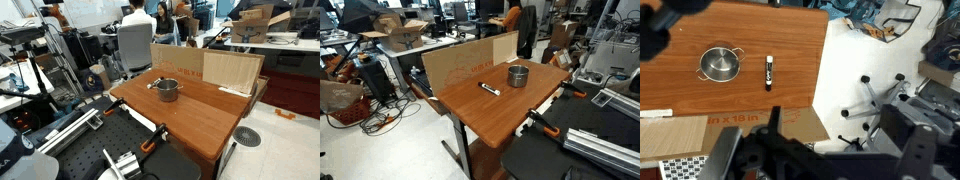

In [10]:
display.Image(as_gif(images, dur=4))

In [11]:
episodes[0].keys()

dict_keys(['action', 'action_dict', 'discount', 'is_first', 'is_last', 'is_terminal', 'language_instruction', 'language_instruction_2', 'language_instruction_3', 'observation', 'reward'])

In [12]:
episodes[0]['action_dict'].keys()

dict_keys(['cartesian_position', 'cartesian_velocity', 'gripper_position', 'gripper_velocity', 'joint_position', 'joint_velocity'])

In [13]:
episodes[0]['observation'].keys()

dict_keys(['cartesian_position', 'exterior_image_1_left', 'exterior_image_2_left', 'gripper_position', 'joint_position', 'wrist_image_left'])

In [27]:
episodes[70]['action']

<tf.Tensor: shape=(7,), dtype=float64, numpy=
array([ 0.62790841,  0.14905195,  0.14770526,  3.00336051,  0.1159564 ,
       -0.09042028,  0.95154184])>

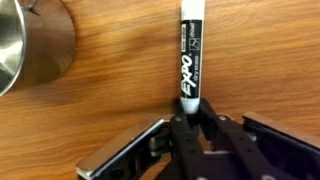

In [26]:
Image.fromarray(episodes[70]['observation']['wrist_image_left'].numpy())

In [14]:
episodes[57]['action_dict']['gripper_position']

<tf.Tensor: shape=(1,), dtype=float64, numpy=array([0.25])>

In [15]:
episodes[57]['action_dict']['joint_position']

<tf.Tensor: shape=(7,), dtype=float64, numpy=
array([ 0.25641227,  0.71375066, -0.0318778 , -1.77288294, -0.08771385,
        2.3238349 ,  0.40536308])>

In [16]:
episodes[57]['action_dict']['cartesian_velocity'][:3] * 1/15

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 0.00907007,  0.00387171, -0.00578768])>

In [17]:
episodes[58]['action'][:3] - episodes[56]['action'][:3]

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 0.00093216,  0.00044422, -0.00438257])>

In [18]:
episodes[58]['observation']['cartesian_position'] - episodes[57]['action'][:6]

<tf.Tensor: shape=(6,), dtype=float64, numpy=
array([-0.01016569, -0.00435501,  0.00633872,  0.0457325 , -0.0105966 ,
       -0.00535486])>

In [19]:
episodes[70]['observation']['gripper_position']

<tf.Tensor: shape=(1,), dtype=float64, numpy=array([0.80616742])>

In [20]:
episodes[69]['action'][6]

<tf.Tensor: shape=(), dtype=float64, numpy=0.9713656306266785>

In [21]:
episodes[0]['observation'].keys()

dict_keys(['cartesian_position', 'exterior_image_1_left', 'exterior_image_2_left', 'gripper_position', 'joint_position', 'wrist_image_left'])

Action stats across all steps in the dataset:
min: [ 0.14057738 -0.53113765 -0.13745312 -3.14157438 -1.48140776 -3.14067602
  0.        ]
max: [0.84986585 0.77035713 0.79913259 3.14157581 1.32678628 3.14008117
 1.        ]
mean: [ 0.52789112  0.00551879  0.31050627  0.35104221 -0.07495361 -0.0029494
  0.4053837 ]
std: [0.11618709 0.17677034 0.15139187 2.95206998 0.29572402 0.81170705
 0.43605361]

Episode length stats for the dataset:
min: 13
max: 1627
mean: 322.12
median: 225.5
p_5: 90.9
p_95: 844.6499999999993


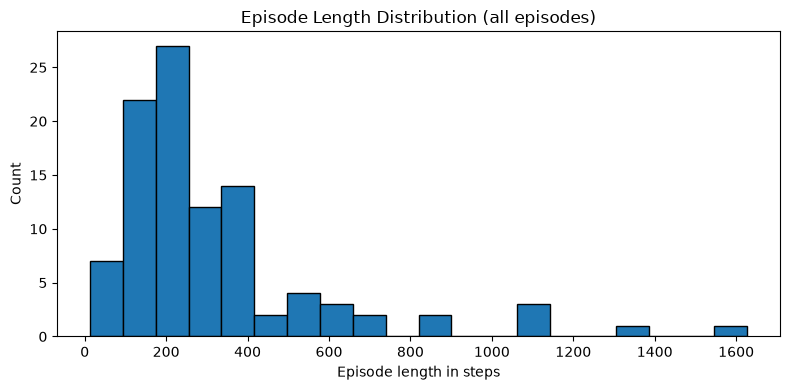

In [30]:
# Analyze all episodes in the split.
num_episodes = None
episode_lengths = []
all_actions = []

episode_iter = tfds.as_numpy(ds) if num_episodes is None else tfds.as_numpy(ds.take(num_episodes))
item = 0
for episode in episode_iter:
    steps = list(episode["steps"])
    episode_lengths.append(len(steps))

    for step in steps:
        item += 1
        all_actions.append(np.asarray(step["action"]))

all_actions = np.asarray(all_actions)
episode_lengths = np.asarray(episode_lengths)

action_stats = {
    "min": all_actions.min(axis=0),
    "max": all_actions.max(axis=0),
    "mean": all_actions.mean(axis=0),
    "std": all_actions.std(axis=0),
}

length_stats = {
    "min": int(episode_lengths.min()),
    "max": int(episode_lengths.max()),
    "mean": float(episode_lengths.mean()),
    "median": float(np.median(episode_lengths)),
    "p_5": float(np.percentile(episode_lengths, 5)),
    "p_95": float(np.percentile(episode_lengths, 95)),
}

print("Action stats across all steps in the dataset:")
for key, value in action_stats.items():
    print(f"{key}: {value}")

print("\nEpisode length stats for the dataset:")
for key, value in length_stats.items():
    print(f"{key}: {value}")

plt.figure(figsize=(8, 4))
plt.hist(episode_lengths, bins=min(20, len(episode_lengths)), edgecolor="black")
plt.title("Episode Length Distribution (all episodes)")
plt.xlabel("Episode length in steps")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [31]:
item

32212

In [23]:
# Verify whether action[:3] is an absolute position or a delta.
# We compare it against the next step's cartesian position and the step-to-step position delta.

num_episodes = None
pos_abs_errors = []
pos_delta_errors = []
pos_next_matches = []
pos_delta_matches = []

episode_iter = tfds.as_numpy(ds) if num_episodes is None else tfds.as_numpy(ds.take(num_episodes))

for episode in episode_iter:
    steps = list(episode["steps"])
    if len(steps) < 2:
        continue

    for i in range(len(steps) - 1):
        action_pos = np.asarray(steps[i]["action"][:3], dtype=np.float64)
        curr_pos = np.asarray(steps[i]["observation"]["cartesian_position"][:3], dtype=np.float64)
        next_pos = np.asarray(steps[i + 1]["observation"]["cartesian_position"][:3], dtype=np.float64)
        delta_pos = next_pos - curr_pos

        pos_abs_errors.append(np.linalg.norm(action_pos - next_pos))
        pos_delta_errors.append(np.linalg.norm(action_pos - delta_pos))
        pos_next_matches.append(np.mean(np.isclose(action_pos, next_pos, atol=1e-3, rtol=1e-3)))
        pos_delta_matches.append(np.mean(np.isclose(action_pos, delta_pos, atol=1e-3, rtol=1e-3)))

pos_abs_errors = np.asarray(pos_abs_errors)
pos_delta_errors = np.asarray(pos_delta_errors)
pos_next_matches = np.asarray(pos_next_matches)
pos_delta_matches = np.asarray(pos_delta_matches)

print("Position check for action[:3]:")
print(f"  mean ||action[:3] - next cartesian_position||: {pos_abs_errors.mean():.6f}")
print(f"  median ||action[:3] - next cartesian_position||: {np.median(pos_abs_errors):.6f}")
print(f"  mean fraction of close dims vs next position: {pos_next_matches.mean():.6f}")
print(f"  mean ||action[:3] - step delta||: {pos_delta_errors.mean():.6f}")
print(f"  median ||action[:3] - step delta||: {np.median(pos_delta_errors):.6f}")
print(f"  mean fraction of close dims vs step delta: {pos_delta_matches.mean():.6f}")

if pos_abs_errors.mean() < pos_delta_errors.mean():
    print("\nConclusion: action[:3] is closer to an absolute position target than a delta.")
else:
    print("\nConclusion: action[:3] is closer to a delta than an absolute position target.")


Position check for action[:3]:
  mean ||action[:3] - next cartesian_position||: 0.022223
  median ||action[:3] - next cartesian_position||: 0.018703
  mean fraction of close dims vs next position: 0.184573
  mean ||action[:3] - step delta||: 0.654968
  median ||action[:3] - step delta||: 0.647290
  mean fraction of close dims vs step delta: 0.001827

Conclusion: action[:3] is closer to an absolute position target than a delta.
